# Normalisation

In [14]:
# load packages
suppressPackageStartupMessages({
    library(Matrix)
    library(scran)
    library(scater)
    library(igraph)
    library(BiocParallel)
})
ncores = 16
mcparam = SnowParam(workers = ncores)
register(mcparam)

main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
dir.create(paste0(main, '04_normalisation/'), showWarnings = FALSE)

source(paste0(main, "core_functions.R"))
load_data(normalise = FALSE)


lib.sizes = Matrix::colSums(counts(sce))
sce = sce[calculateAverage(sce)>0.1,]

In [15]:
clusts = as.numeric(quickCluster(sce, method = "igraph", min.size = 100, BPPARAM = mcparam))

In [16]:
#now run the normalisation
#number of cells in each cluster should be at least twice that of the largest 'sizes'
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
sce = computeSumFactors(sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)


p1 = ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") +
  theme_bw() + 
  theme(text = element_text(size=20)) 

Saving 6.67 x 6.67 in image



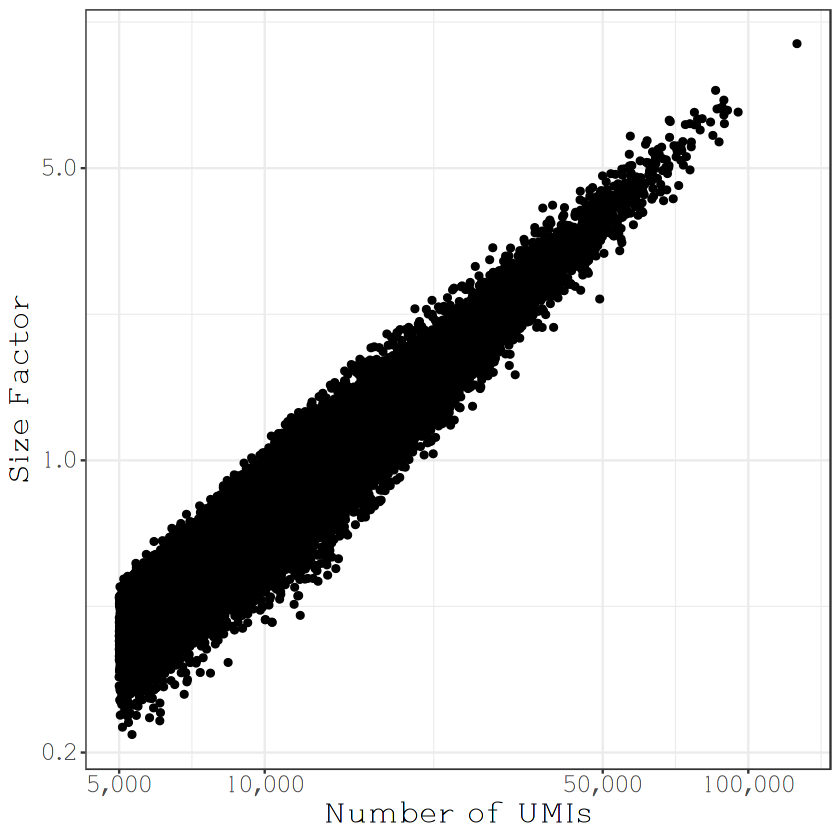

In [22]:
p1
ggsave(paste0(main, '04_normalisation/size_factors.png'), p1, device='png')

In [18]:
write.table(sizeFactors(sce), quote = F, col.names = F, row.names = F, file = paste0(main, "04_normalisation/sizefactors.tab"))

In [ ]:
sessionInfo()